## 4.AutoML을 통한 데이터 예측

- AutoML은 ML 기반 모델링에서 반복적으로 수행되는 작업을 자동으로 수행해주는 라이브러리입니다.

- 기존의 ML 알고리즘인 decision_tree, random_forest, SVC, Bayesian Classifier와 앙상블 기법들을 최대한 활용하여, 성능이 안정적으로 나오는 모델을 저장한다.

### 4.1 Data Load

In [1]:
from sklearn.datasets import fetch_openml
import copy
from pathlib import Path

path_lecture = Path("data")
adult_data = fetch_openml(name="adult", version=2, as_frame=True)
raw_df = adult_data.frame
raw_df.to_csv(path_lecture / "adult_income.csv", index=False)

display(raw_df.head())
print(f"Data Shape: {raw_df.shape}", end="\n\n")

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


Data Shape: (48842, 15)



### 4.2 Pre-processing

In [2]:
from aif360.datasets import BinaryLabelDataset
from sklearn.preprocessing import LabelEncoder

df = copy.deepcopy(raw_df)
df = df.dropna(how="any")

drop_columns = ["education"]
encoding_columns = ["workclass","marital-status","occupation","relationship","race","sex","native-country",'class']
df_filtered = df.drop(columns=drop_columns)

encoding_mappings = {}
for col in encoding_columns:
    le = LabelEncoder()
    df_filtered[col] = le.fit_transform(df_filtered[col].astype(str)) 
    encoding_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

### 4.3 Model

In [3]:
from autogluon.tabular import TabularPredictor
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
random_state = 42
train_orig = df_filtered.sample(frac=0.8, random_state=random_state)
test_orig = df_filtered.drop(train_orig.index)

predictor_original = TabularPredictor(label="class").fit(train_orig)

/home/paradeigma/workspace/mlops/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No path specified. Models will be saved in: "AutogluonModels/ag-20250408_110054"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.9.21
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Fri Mar 29 23:14:13 UTC 2024
CPU Count:          24
Memory Avail:       11.70 GB / 15.18 GB (77.1%)
Disk Space Avail:   690.71 GB / 1006.85 GB (68.6%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='ex

### 4.4 Prediction

In [4]:
y_pred_orig = predictor_original.predict(test_orig)
y_prob_orig = predictor_original.predict_proba(test_orig)[1]
y_test_orig = test_orig["class"]

In [5]:
# 참조: https://angeloyeo.github.io/2020/08/05/ROC.html#google_vignette
def evaluate_model(y_true, y_pred, y_prob, title="Model Performance"):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    print(f"{title}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")

    return acc, f1, auc, fpr, tpr

acc_orig, f1_orig, auc_orig, fpr_orig, tpr_orig = evaluate_model(y_test_orig, y_pred_orig, y_prob_orig, "Normal")

Normal
Accuracy: 0.8684
F1 Score: 0.7126
AUC: 0.9233


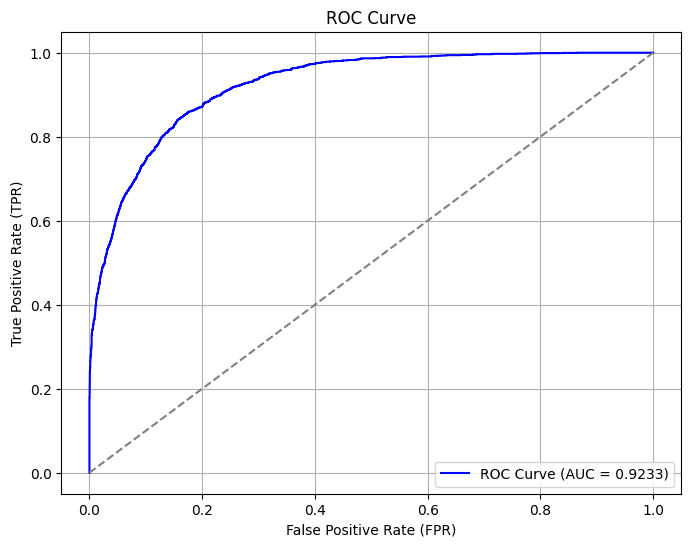

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr_orig, tpr_orig, color='blue', label=f'ROC Curve (AUC = {auc_orig:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

참조: https://angeloyeo.github.io/2020/08/05/ROC.html